# **Part-1**

# **Step-1**

In [205]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [206]:
df = pd.read_csv('dataset.csv')

print("Dataset Head:")
display(df.head())

print("Dataset Info:")
print(df.info())

Dataset Head:


,f1,f2,f3,f4,f5,f6,f7,target
0,6,148,72,35,0,33.6,0.627,1
1,1,85,66,29,0,26.6,0.351,0
2,8,183,64,0,0,23.3,0.672,1
3,1,89,66,23,94,28.1,0.167,0
4,0,137,40,35,168,43.1,2.288,1


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 766 entries, 0 to 765
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   f1      766 non-null    object
 1   f2      766 non-null    object
 2   f3      766 non-null    int64 
 3   f4      766 non-null    object
 4   f5      766 non-null    object
 5   f6      766 non-null    object
 6   f7      766 non-null    object
 7   target  766 non-null    int64 
dtypes: int64(2), object(6)
memory usage: 48.0+ KB
None


In [207]:
print("Stats:")
print(df.describe())

print("Missing Values:")
print(df.isnull().sum())

Stats:
               f3      target
count  766.000000  766.000000
mean    69.118799    0.349869
std     19.376901    0.477240
min      0.000000    0.000000
25%     62.500000    0.000000
50%     72.000000    0.000000
75%     80.000000    1.000000
max    122.000000    1.000000
Missing Values:
f1        0
f2        0
f3        0
f4        0
f5        0
f6        0
f7        0
target    0
dtype: int64


There are no missing values in the dataset

In [208]:
for col in df.columns:
    print(f"Unique values in {col}:")
    print(df[col].unique())

Unique values in f1:
['6' '1' '8' '0' '5' '3' '10' '2' '4' '7' '9' '11' '13' '15' '17' '12'
 '14' 'c']
Unique values in f2:
['148' '85' '183' '89' '137' '116' '78' '115' '197' '125' '110' '168'
 '139' '189' '166' '100' '118' '107' '103' '126' '99' '196' '119' '143'
 '147' '97' '145' '117' '109' '158' '88' '92' '122' '138' '102' '90' '111'
 '180' '133' '106' '171' '159' '146' '71' '105' '101' '176' '150' '73'
 '187' '84' '44' '141' '114' '95' '129' '79' '0' '62' '131' '112' '113'
 '74' '83' '136' '80' '123' '81' '134' '142' '144' '93' '163' '151' '96'
 '155' '76' '160' '124' '162' '132' '120' '173' '170' '128' '108' '154'
 '57' '156' '153' '188' '152' '104' '87' '75' '179' '130' '194' '181'
 '135' '184' '140' '177' '164' '91' '165' '86' '193' '191' '161' '167'
 '77' '182' '157' '178' '61' '98' '127' '82' '72' '172' '94' '175' '195'
 '68' '186' '198' '121' '67' '174' '199' '56' '169' '149' '65' '190' 'f']
Unique values in f3:
[ 72  66  64  40  74  50   0  70  96  92  80  60  84  30  88  

In [209]:
#We are replacing the invalid values by NaN here.
df.replace(['a', 'b', 'c', 'd', 'e', 'f'], np.nan, inplace=True)

In [210]:
# Here we are converting columns into numeric and filling nan values with mean.
df = df.apply(pd.to_numeric, errors='coerce')
df.fillna(df.mean(), inplace=True)

In [211]:
#Target class is not balanced
print(df['target'].value_counts())

target
0    498
1    268
Name: count, dtype: int64


In [212]:
print("Dataset Info:")
print(df.info())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 766 entries, 0 to 765
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   f1      766 non-null    float64
 1   f2      766 non-null    float64
 2   f3      766 non-null    int64  
 3   f4      766 non-null    float64
 4   f5      766 non-null    float64
 5   f6      766 non-null    float64
 6   f7      766 non-null    float64
 7   target  766 non-null    int64  
dtypes: float64(6), int64(2)
memory usage: 48.0 KB
None


# Visualisations

Text(0.5, 1.0, 'Feature Correlation Heatmap')

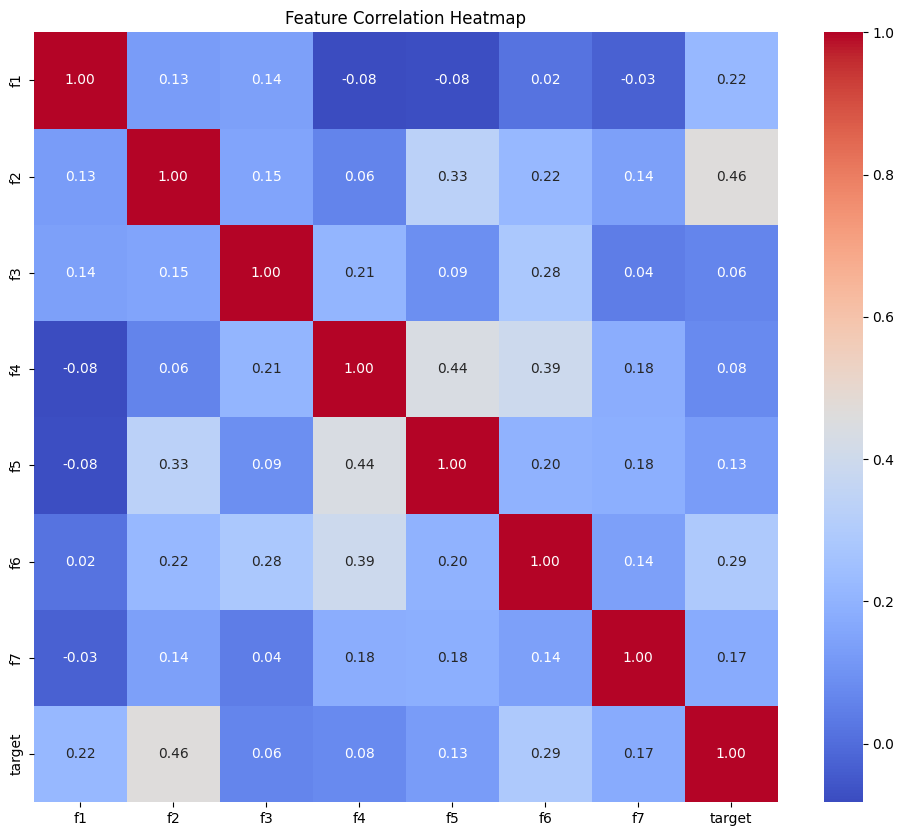

In [213]:
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')

# **Observations of the above visualization**
The above figure is a co-relation heatmap:


*   The feature f2 is strongly co-related with the target.
*   f3,f4 are weakly co-related with the target.







Text(0.5, 1.02, 'Distribution of All Variables')

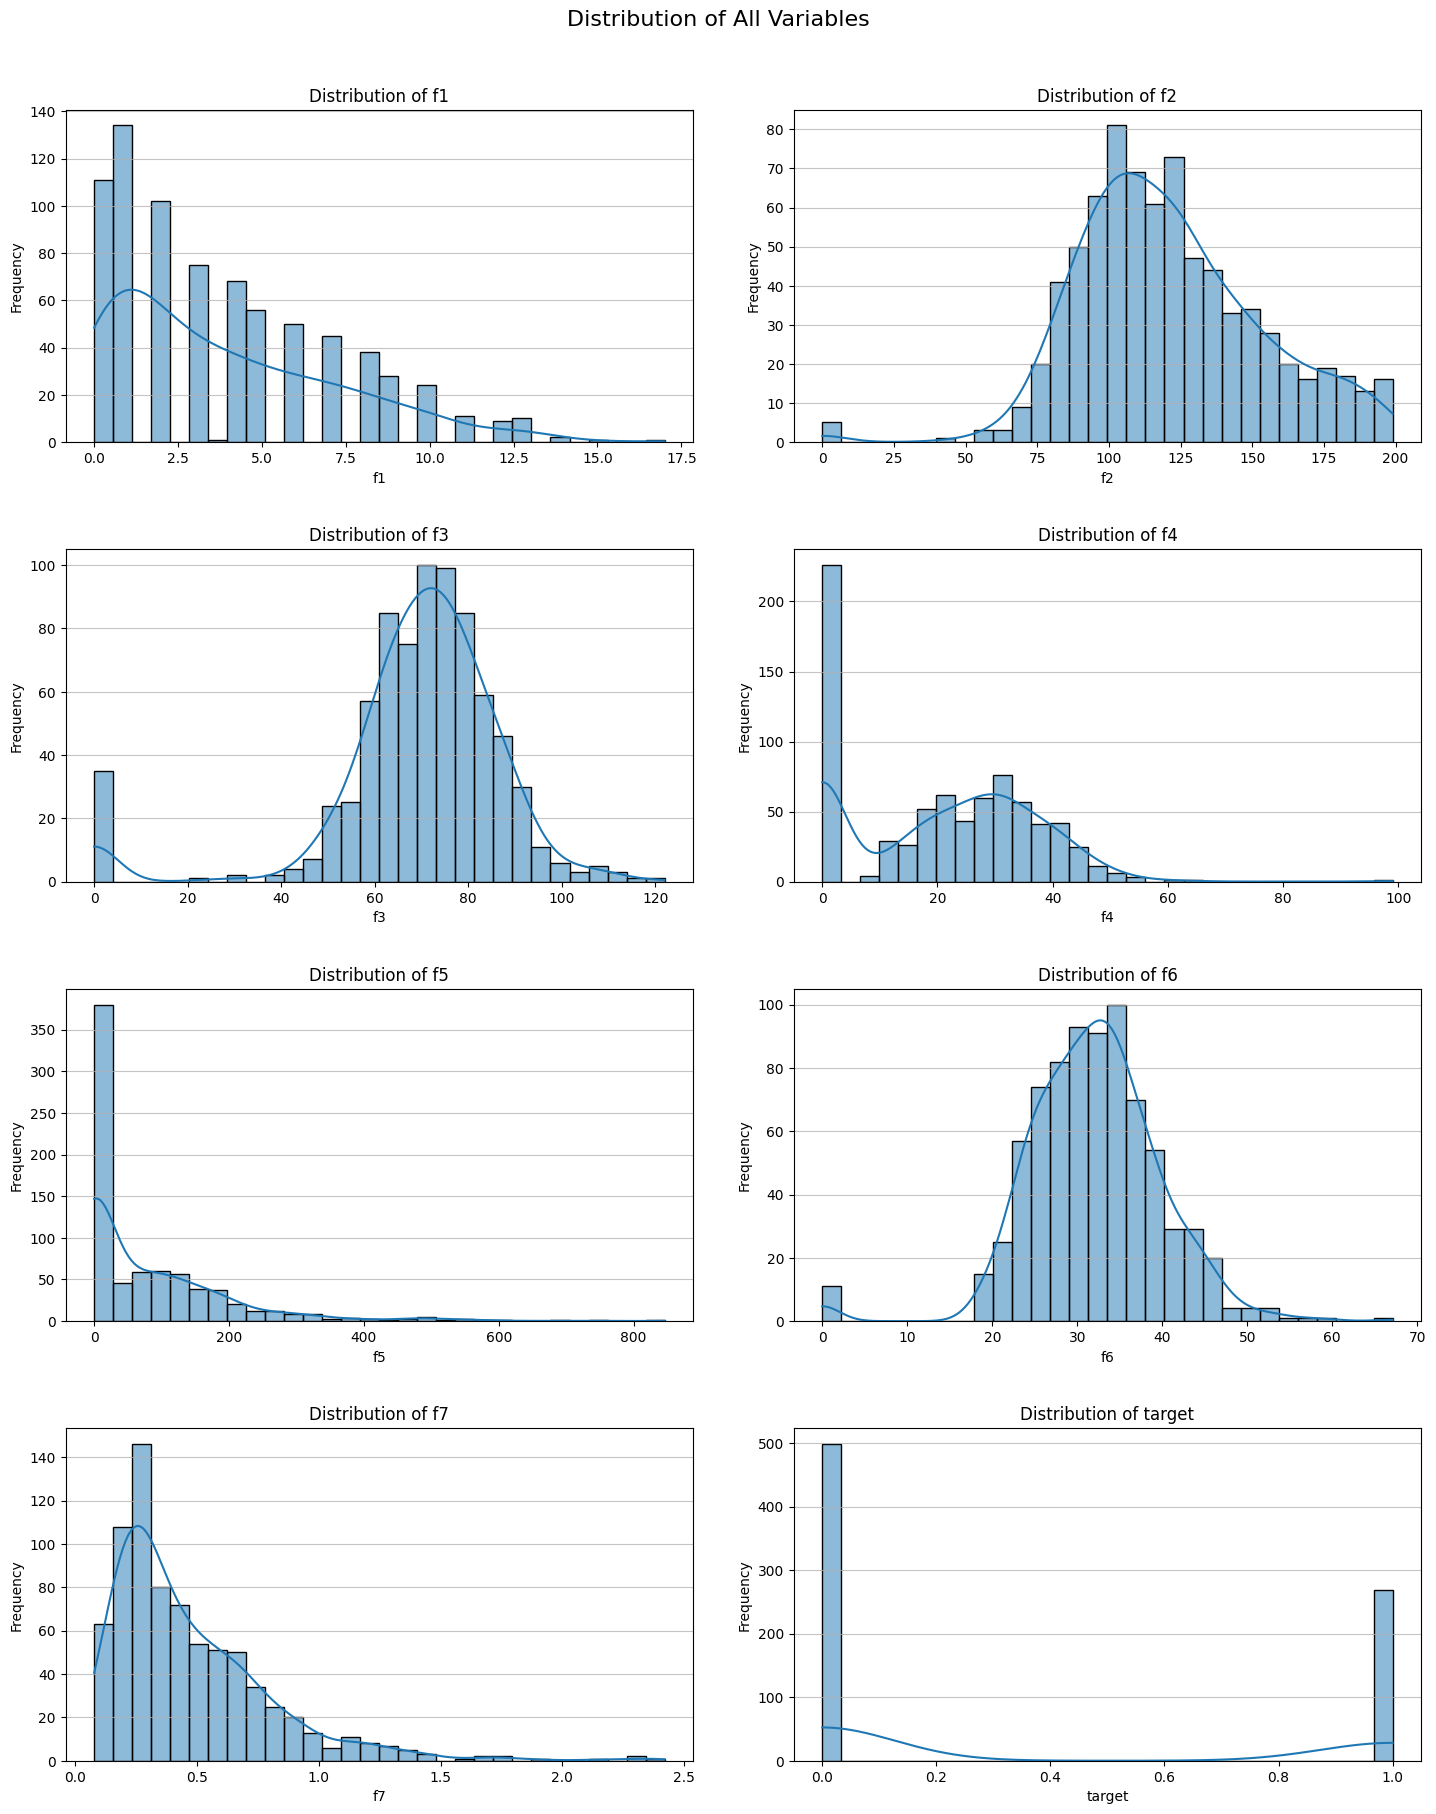

In [214]:

n_rows = 4
n_cols = 2
fig,axes = plt.subplots(n_rows,n_cols,figsize=(15,18))
axes = axes.flatten()
for i, col in enumerate(df.columns):
    sns.histplot(df[col], kde=True,bins=30,ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(axis='y', alpha=0.75)

for i in range(len(df.columns),len(axes)):
    fig.delaxes(axes[i])
plt.tight_layout(pad=3.0)
fig.suptitle('Distribution of All Variables',fontsize=16,y=1.02)



# **Observations of the above visualization**

*   f1, f5, f7 -  Shows right-skewed distribution
*   f2,f3,f6 - Bell Curve Distribution
*   f4 - Shows highly right skewed distribution





Text(0.5, 0.98, 'Scatter Plot Matrix of All Features')

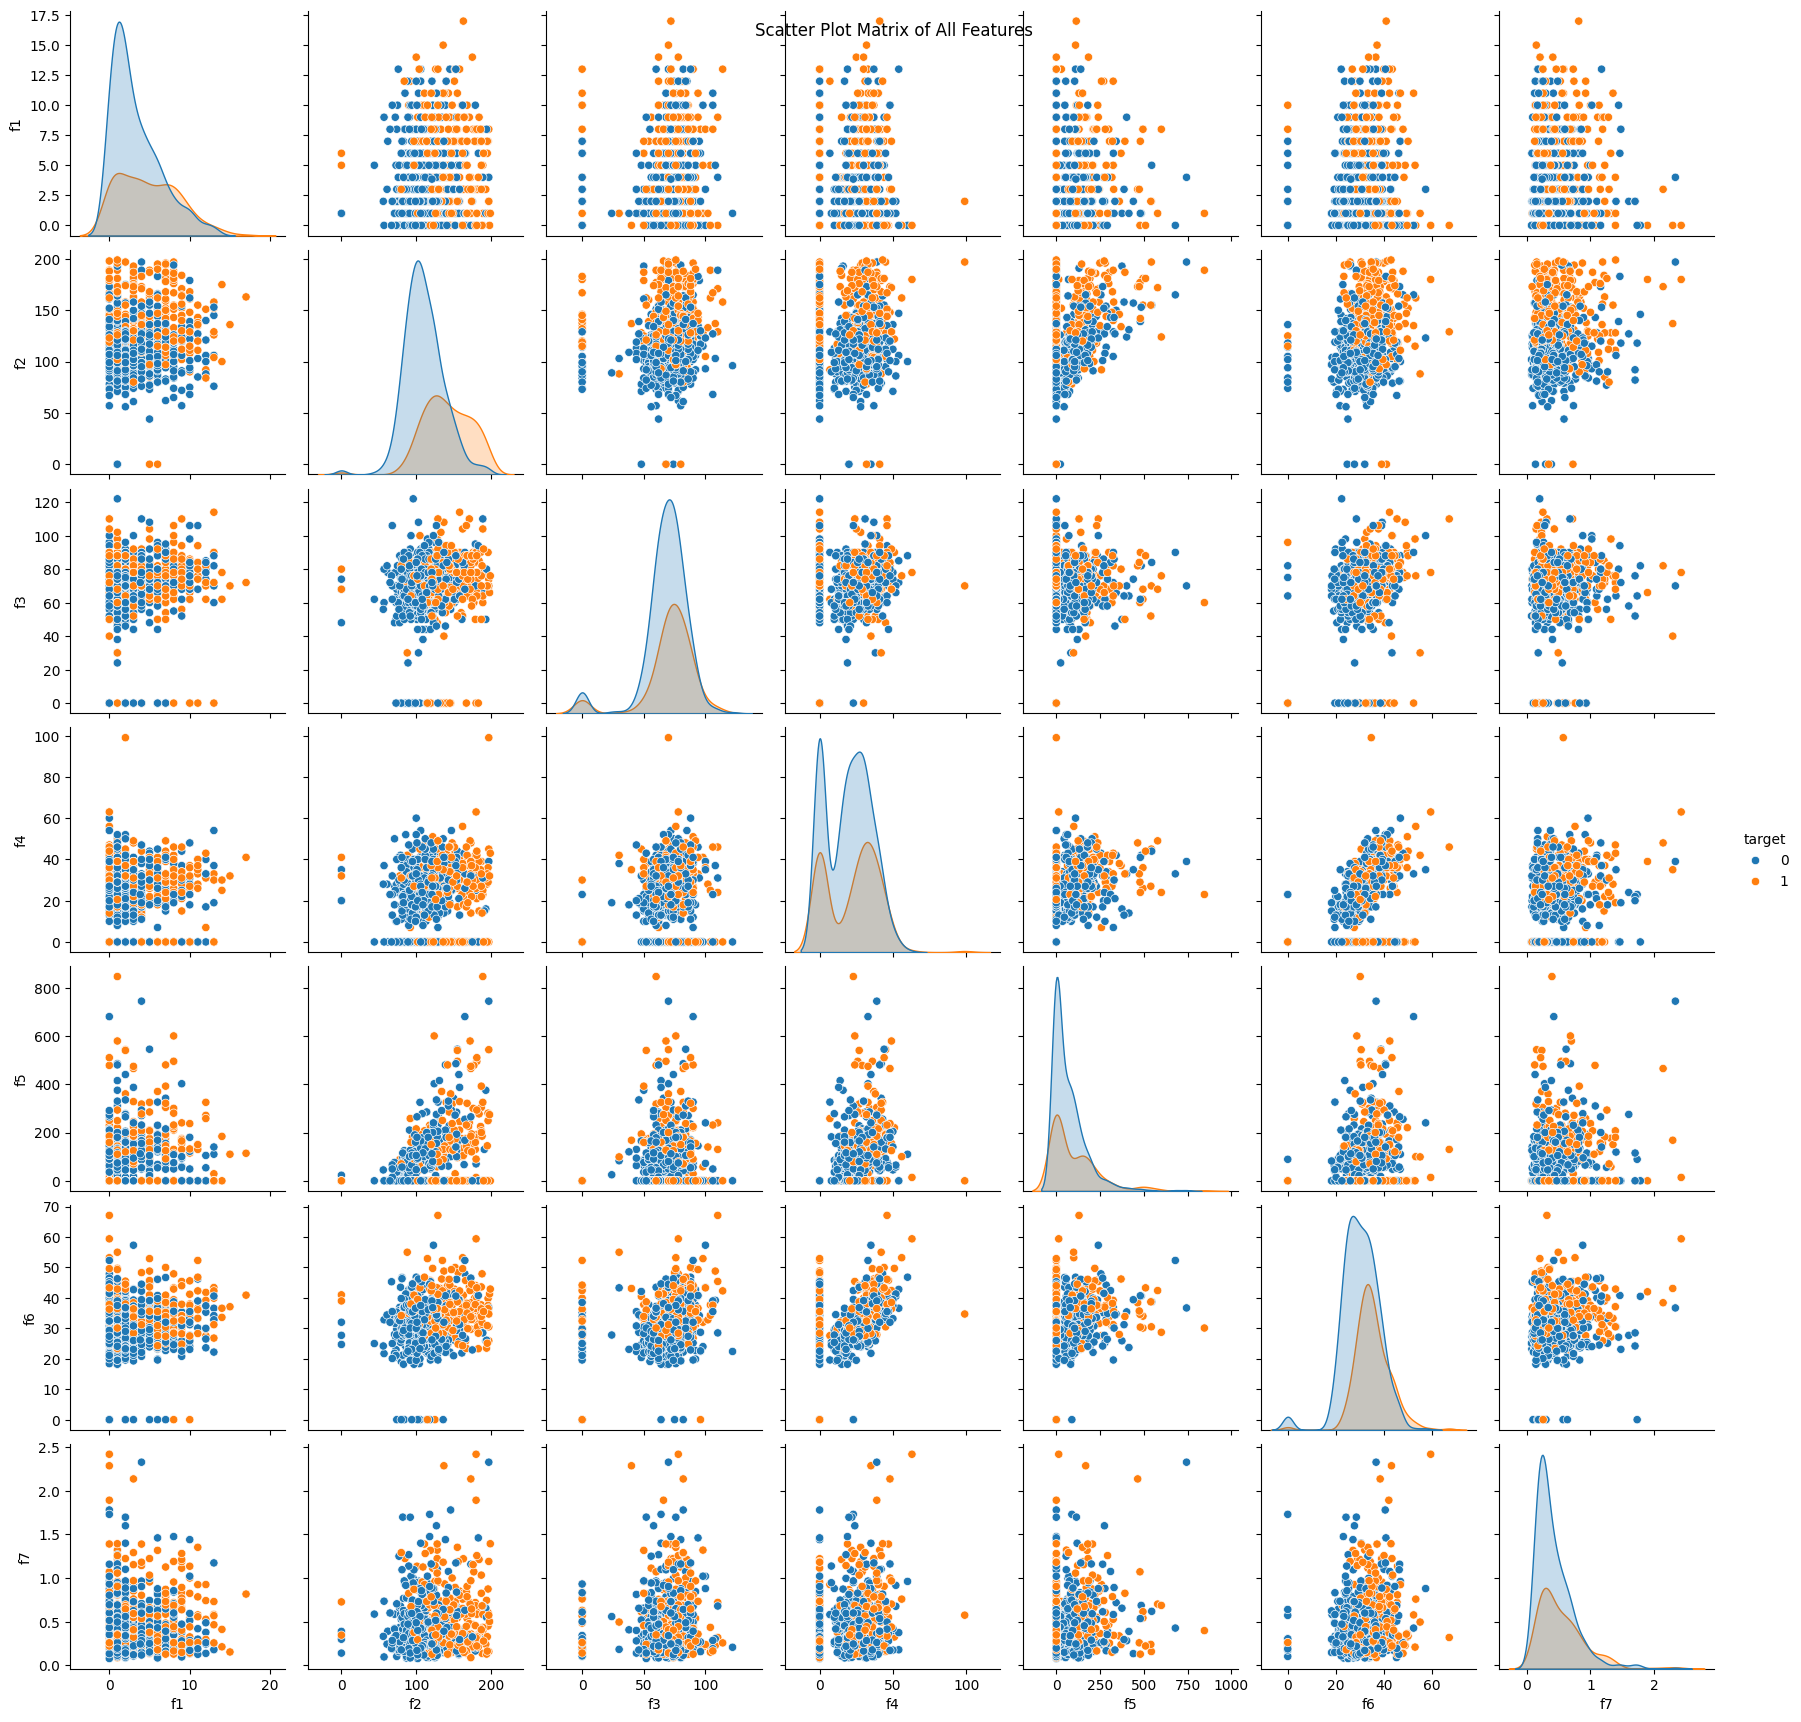

In [215]:

feature_columns = [col for col in df.columns if col.startswith('f')]
pairplot = sns.pairplot(df, vars=feature_columns,hue='target')
pairplot.fig.suptitle('Scatter Plot Matrix of All Features')



# **Observations of the above visualization**


*   A Scatter plot is visualised between each feature in the dataset.
*   A Strong linear relationships are visible between certain feature like (f2-f6, f2-f3, f3-f4).


*   Features f2, f3, and f6 show class separation in the distributions.






# Step-2

In [216]:
# Sampling the minority class (target=1) to match the size of the majority class (target=0) through random resampling with replacement.
from sklearn.utils import resample
df_zero = df[df.target == 0]
df_one = df[df.target == 1]
df_minority_upsampled = resample(df_one,replace=True, n_samples=len(df_zero),random_state=42)
df = pd.concat([df_zero, df_minority_upsampled])
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
X = df.drop('target', axis=1)
y = df['target']

In [217]:
#Z-score normalisation is performed.
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [218]:
#Target is now balanced
print(y.value_counts())

target
1    498
0    498
Name: count, dtype: int64


In [219]:
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [220]:
# data is split into 80% for training and 20%  testing.
#Then, the training set is further divided into 60% for training and 20% for validation
X_train_val, X_test, y_train_val, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)


Train shape: (597, 7)
Validation shape: (199, 7)
Test shape: (200, 7)


In [221]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).unsqueeze(1)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

# **Pre-Processing Steps**

*   Oversampling is performed as number of zeroes -  498 and number of ones - 268



*   Z-score normalisation is performed.
*   Data is split into 80% for training and 20% testing. Then, the training set is further divided into 60% for training and 20% for validation

*   One hot encoding not required as there are no categorical columns.
*   The training, validation, and test datasets from NumPy arrays are converted into PyTorch tensors.





# **Step-3**

In [222]:
!pip install torchinfo

In [223]:
import torch.nn as nn
import torch.nn.functional as F
from torchinfo import summary


In [224]:
#Q- 1,2,3
class Neural_Network(nn.Module):
    def __init__(self, input_dim):
        super(Neural_Network, self).__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.fc3 = nn.Linear(128, 64)
        self.bn3 = nn.BatchNorm1d(64)
        self.fc4 = nn.Linear(64, 1)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = F.relu(self.bn2(self.fc2(x)))
        x = self.dropout(x)
        x = F.relu(self.bn3(self.fc3(x)))
        x = self.dropout(x)
        x = self.fc4(x)
        return x


input_dim = X_train_tensor.shape[1]
model = Neural_Network(input_dim)


from torchinfo import summary
summary(model, input_size=(X_train_tensor.shape[0], input_dim))


Layer (type:depth-idx)                   Output Shape              Param #
Neural_Network                           [597, 1]                  --
├─Linear: 1-1                            [597, 128]                1,024
├─BatchNorm1d: 1-2                       [597, 128]                256
├─Dropout: 1-3                           [597, 128]                --
├─Linear: 1-4                            [597, 128]                16,512
├─BatchNorm1d: 1-5                       [597, 128]                256
├─Dropout: 1-6                           [597, 128]                --
├─Linear: 1-7                            [597, 64]                 8,256
├─BatchNorm1d: 1-8                       [597, 64]                 128
├─Dropout: 1-9                           [597, 64]                 --
├─Linear: 1-10                           [597, 1]                  65
Total params: 26,497
Trainable params: 26,497
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 15.82
Input size (MB): 0.02
Forward/b

In [225]:
def forward(self, x):
    x = F.relu(self.bn1(self.fc1(x)))
    x = self.dropout(x)
    x = F.relu(self.bn2(self.fc2(x)))
    x = self.dropout(x)
    x = F.relu(self.bn3(self.fc3(x)))
    x = self.dropout(x)
    x = self.fc4(x)
    return x

# **Step-4**

In [226]:
#1) Binary Cross-Entropy Loss with Logits Is the loss function used here which combines loss function and sigmoid activation layer
criterion = nn.BCEWithLogitsLoss()

In [227]:
#2) Stochastic Gradient Descent optimizer is used here with learning rate = 0.001 and momemtum = 0.96
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.95)


In [228]:
# Training and validation tensors are converted into Dataset objects, then  DataLoaders are created that input data to the model in batches of 32 samples at a time.
from torch.utils.data import TensorDataset, DataLoader

training_data = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_data_loaded = DataLoader(training_data, batch_size=32, shuffle=True)
validation_data_loaded= DataLoader(val_dataset, batch_size=32)

In [229]:
print(y_train_tensor.unique())
print(y_val_tensor.unique())

tensor([0., 1.])
tensor([0., 1.])


In [230]:
#Q-3,4,5 Training loop
# Best Model is stored in best_model.pth
# Best weights stored in best_weights.pkl
#Lists are created to store, accuracy,losses during training and validation steps for plotting
#100 Epochs are considered
# Later evaluating it on validation data without updating weights.
import time
import pickle

accuracylist_training = []
accuracylist_validation = []
losslist_training = []
losslist_validation = []

num_epochs = 100
validationLoss_best = None
start_time = time.time()
for epoch in range(num_epochs):
    model.train()
    correct = 0
    total = 0
    running_loss = 0.0

    for inputs, labels in train_data_loaded:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss = running_loss + loss.item() * inputs.size(0)
        preds = torch.round(torch.sigmoid(outputs))
        correct = correct + (preds == labels).sum().item()
        total = total + labels.size(0)

    traningLoss = running_loss / total
    accuracy_epoch = correct / total
    losslist_training.append(traningLoss)
    accuracylist_training.append(accuracy_epoch)

    model.eval()
    validation_loss = 0.0
    validation_correct = 0
    validation_total = 0
    with torch.no_grad():
        for validation_input_data, val_labels in validation_data_loaded:
            validation_output_data = model(validation_input_data)
            loss = criterion(validation_output_data, val_labels)
            validation_loss += loss.item() * validation_input_data.size(0)
            val_preds = torch.round(torch.sigmoid(validation_output_data))
            correct_predictions = (val_preds == val_labels)
            validation_correct += correct_predictions.sum().item()
            validation_total += val_labels.size(0)

    val_loss_epoch = validation_loss / validation_total
    val_acc_epoch = validation_correct / validation_total
    losslist_validation.append(val_loss_epoch)
    accuracylist_validation.append(val_acc_epoch)

    if validationLoss_best is None or val_loss_epoch < validationLoss_best:
        validationLoss_best = val_loss_epoch
        torch.save(model.state_dict(), "best_model.pth")
        with open("best_weights.pkl", "wb") as f:
            pickle.dump(model.state_dict(), f)
    print(f"Epoch [{epoch+1}] - Training Loss: {traningLoss:.4f}, Train Accuracy: {accuracy_epoch:.4f}, Validation Loss: {val_loss_epoch:.4f}, Validation Accuracy: {val_acc_epoch:.4f}")

end_time = time.time()
print(f"Training model completed in: {end_time - start_time:.2f} s")


Epoch [1] - Training Loss: 0.7111, Train Accuracy: 0.5193, Validation Loss: 0.6806, Validation Accuracy: 0.6131
Epoch [2] - Training Loss: 0.6675, Train Accuracy: 0.5913, Validation Loss: 0.6380, Validation Accuracy: 0.6633
Epoch [3] - Training Loss: 0.6220, Train Accuracy: 0.6667, Validation Loss: 0.6098, Validation Accuracy: 0.6834
Epoch [4] - Training Loss: 0.6035, Train Accuracy: 0.7035, Validation Loss: 0.5903, Validation Accuracy: 0.6935
Epoch [5] - Training Loss: 0.5787, Train Accuracy: 0.6918, Validation Loss: 0.5784, Validation Accuracy: 0.7085
Epoch [6] - Training Loss: 0.5688, Train Accuracy: 0.7069, Validation Loss: 0.5706, Validation Accuracy: 0.7236
Epoch [7] - Training Loss: 0.5681, Train Accuracy: 0.7152, Validation Loss: 0.5657, Validation Accuracy: 0.7236
Epoch [8] - Training Loss: 0.5562, Train Accuracy: 0.7152, Validation Loss: 0.5611, Validation Accuracy: 0.7337
Epoch [9] - Training Loss: 0.5479, Train Accuracy: 0.7270, Validation Loss: 0.5605, Validation Accuracy:

In [231]:
# Dataset from the test features and labels is created and then wrapped  in a DataLoader that processes the test data in batches of 32 samples without shuffling.
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [232]:
print(y_train_tensor.unique())
print(y_val_tensor.unique())

tensor([0., 1.])
tensor([0., 1.])


In [233]:
#6
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

y_true = []
y_predictions = []
test_loss = 0.0
test_correct = 0
test_total = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        test_loss = test_loss + loss.item() * inputs.size(0)
        output_probs = torch.sigmoid(outputs)
        y_predictions.extend(output_probs.numpy())
        preds = torch.round(output_probs)
        test_correct += (preds == labels).sum().item()
        y_true.extend(labels.numpy())
        test_total = test_total + labels.size(0)


test_accuracy = test_correct / test_total
test_loss = test_loss / test_total
y_pred_binary = np.round(y_predictions)
print(f"\nTest Data Accuracy: {test_accuracy * 100:.2f}%")
print(f"\nTest Data Loss: {test_loss * 100:.2f}%")


Test Data Accuracy: 80.00%

Test Data Loss: 48.50%


In [234]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score


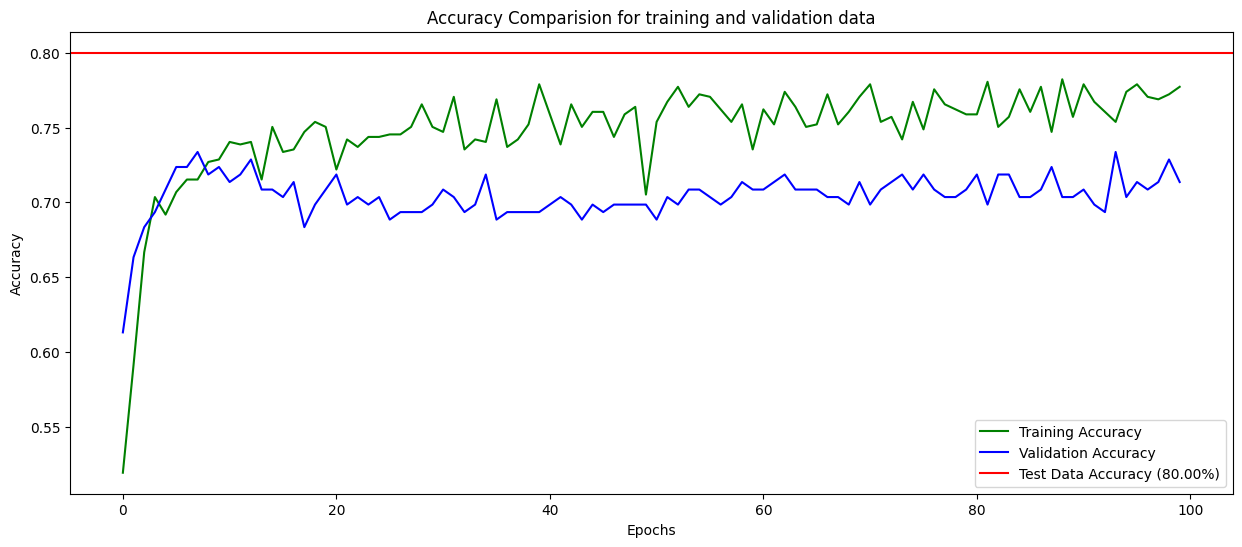

In [235]:
#7
plt.figure(figsize=(15, 6))
plt.plot(accuracylist_training, label='Training Accuracy', color='green')
plt.plot(accuracylist_validation, label='Validation Accuracy', color='blue')
plt.axhline(y=test_accuracy, label=f'Test Data Accuracy ({test_accuracy:.2%})', color='red', linestyle='-')
plt.title('Accuracy Comparision for training and validation data')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# **Observations** -

*   Training and validation accuracy increases rapidly in the initial number of epochs.
*   Training accuracy is higher than the validation accuracy in the later epochs.


*   The test accuracy is higher than the training and validation accuracy.






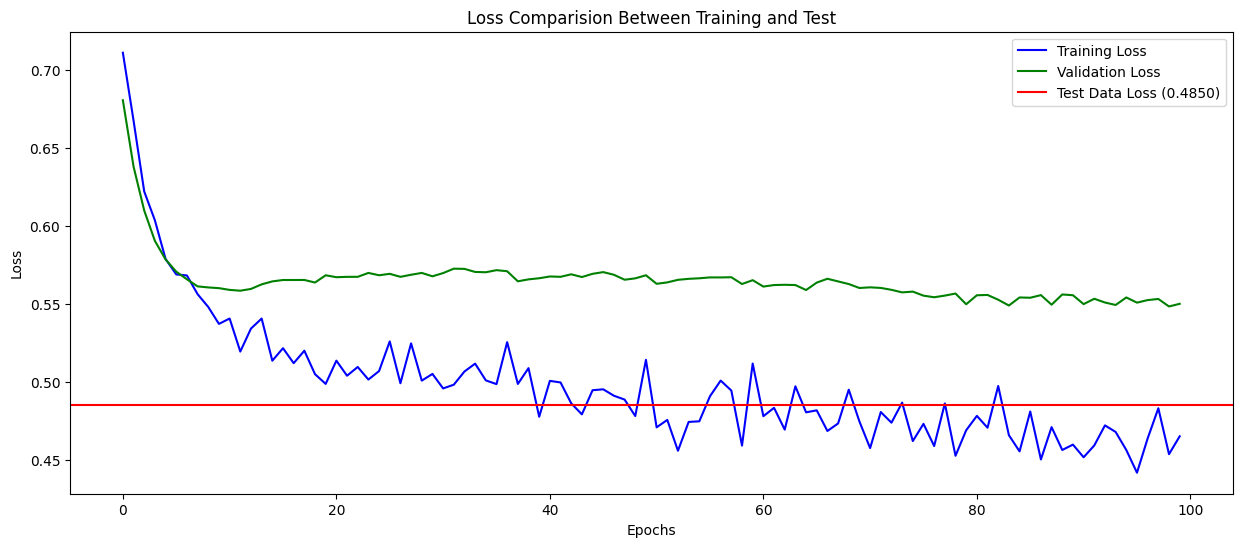

In [236]:

plt.figure(figsize=(15, 6))
plt.plot(losslist_training, label='Training Loss', color='blue')
plt.plot(losslist_validation, label='Validation Loss', color='green')
plt.axhline(y=test_loss, label=f'Test Data Loss ({test_loss:.4f})', color='red', linestyle='-')
plt.title('Loss Comparision Between Training and Test')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# **Observations:**


*   The training and validation loss decrease rapidly in the initial 20 epochs.
*   The training loss keeps decreasing while the validation loss plateaus at around 0.57.


*   The test loss is lower than the validation loss but sligthly higher than the training loss and hovers around at the same value.






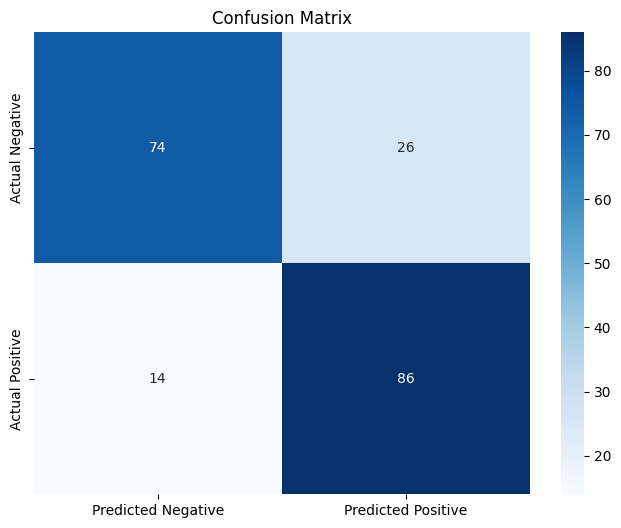

In [237]:
confusion_matrix = confusion_matrix(y_true, y_pred_binary)
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues',xticklabels=['Predicted Negative', 'Predicted Positive'],yticklabels=['Actual Negative', 'Actual Positive'])
plt.title('Confusion Matrix')
plt.show()

# **Observations**


*  The model correctly identified 86 out of 100 true positives
achieving 86% recall for the positive class, this indicates that it effectively detects positive instances with few mistakes.

*   The model correctly identified 76 out of 100 true negatives, achieving 76% recall for the negative class, indicating that it effectively detects negative instances



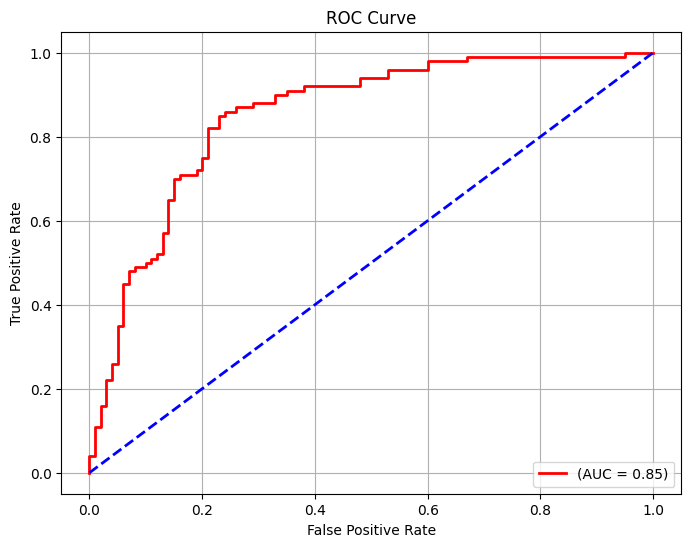

In [238]:
false_positive_rate, true_positive_rate, _ = roc_curve(y_true, np.array(y_predictions).flatten())
auc = roc_auc_score(y_true, y_predictions)
plt.figure(figsize=(8, 6))
plt.plot(false_positive_rate, true_positive_rate, color='red', lw=2, label=f'(AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='blue', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# **Observations:**

*   The curve shows that the model has strong classification aspects as the ROC curve is situated above the baseline.
*  When we look into the curve, the initial increase shows the model has 60% true positive rate with only 10% false positive rate.

*  The model has a AUC of 0.86, which indicates that,  model has an 86% probability of correctly choosing a  positive value higher than a negative value.






# **References:**



*   Dataset used - https://ublearns.buffalo.edu/d2l/common/viewFile.d2lfile/Database/ODg2MzYyNw/datasets.zip?ou=317287
*   Pytorch tutorials - https://pytorch.org/tutorials/beginner/deep_learning_60min_blitz.html


*   Torchinfo - https://github.com/TylerYep/torchinfo
*   ROC Specifications - https://developers.google.com/machine-learning/crash-course/classification/roc-and-auc


*   Python Docs ( For time calculation)- https://docs.python.org/3/library/time.html



*   Optimizers - https://www.geeksforgeeks.org/deep-learning/optimizers-in-tensorflow/










# **Contributions**

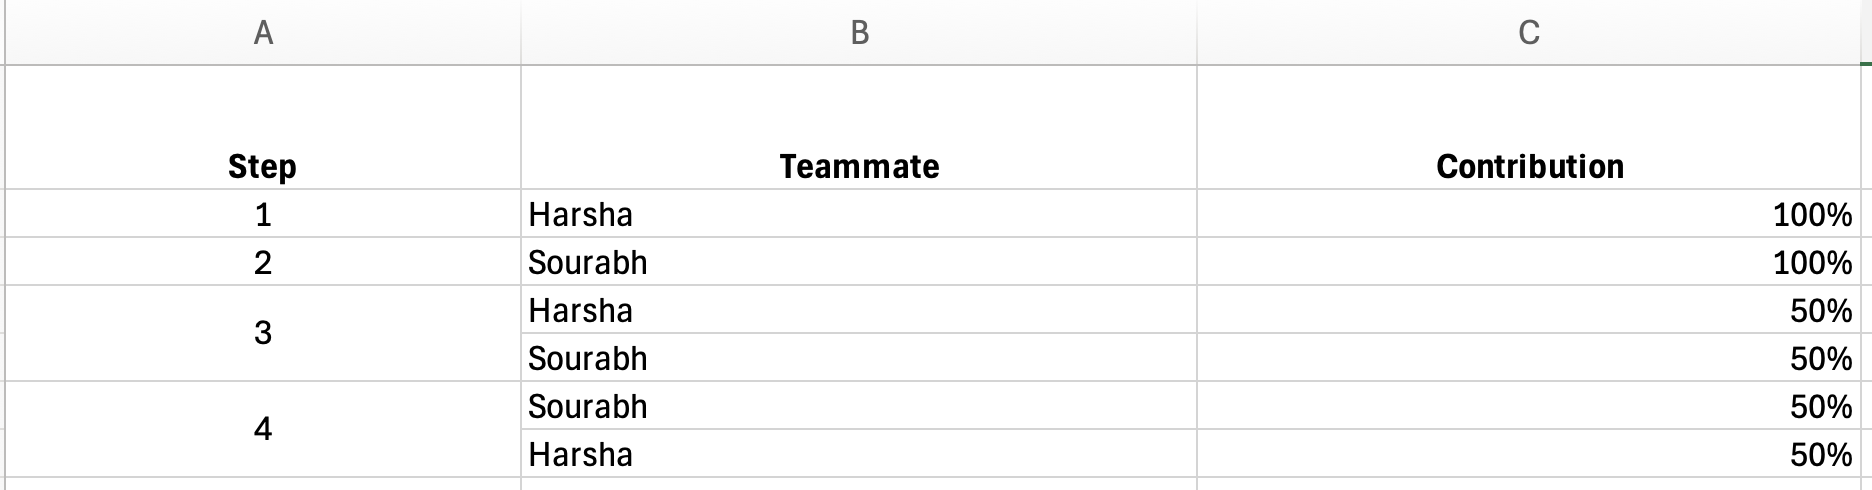